In [1]:
import numpy as np
from pysr import *

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
X = 2 * np.random.randn(100, 5)
y = 2 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 2

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:

model = PySRRegressor(
    niterations=500,
    population_size=50,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[
        "inv(x) = 1/x"
    ],
    extra_sympy_mappings={
        "inv": lambda x: 1/x,
    },
)

model.fit(X_train, y_train)

/home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 7.540e+05
Progress: 2090 / 15500 total iterations (13.484%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.118e+01  0.000e+00  y = 2.1604
3           4.582e+00  1.098e+00  y = x₀ * x₀
4           4.582e+00  -0.000e+00  y = x₀ / inv(x₀)
5           1.794e+00  9.375e-01  y = (x₀ * x₀) - 1.6691
6           1.794e+00  -0.000e+00  y = (x₀ / inv(x₀)) + -1.6696
7           1.716e+00  4.462e-02  y = (x₀ * (x₀ + -0.14561)) + -1.6157
8           1.666e+00  2.923e-02  y = (x₀ / (inv(x₀) - -0.0088737)) + -1.6585
9           1.584e+00  5.088e-02  y = ((x₀ - (x₃ * -0.1105)) * x₀) + -1.5689
11          6.397e-01  4.533e-01  y = inv(-0.23101 - inv(x₃ * x₃)) + (x₀ * x₀)
13          4.494e-01  1.766e-01  y = (x₀ * x₀) - inv(inv(x₃ * (x₃ / 0.49033)) + 0.27757)
14

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,['inv(x) = 1/x']
,expression_spec,None
,niterations,500
,populations,31
,population_size,50
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - /tmp/tmpmxh0ebtk/20250917_120339_tPSCtW/hall_of_fame.csv


In [5]:
from sklearn.metrics import mean_squared_error as MSE

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = MSE(y_train, y_train_pred)**(1/2)
rmse_test  = MSE(y_test, y_test_pred)**(1/2)

print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")


Train RMSE: 0.0272
Test RMSE: 0.0231


In [6]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")

Train R²: 1.0000
Test R²: 1.0000


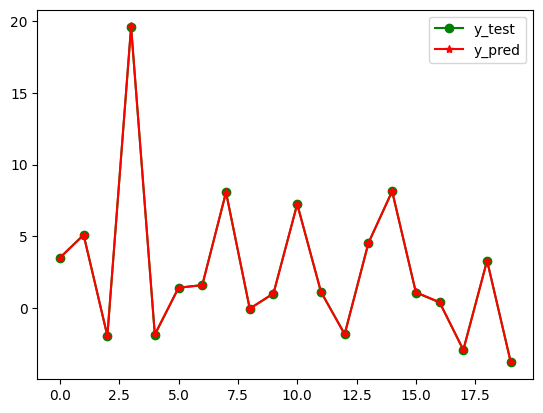

In [7]:
import matplotlib.pyplot as plt
x_axis = np.arange(len(y_test))

plt.plot(x_axis, y_test, color='g', marker="o", label='y_test')
plt.plot(x_axis, y_test_pred, color='r', marker="*", label='y_pred')
plt.legend()
plt.show()

In [8]:
print(model.sympy())

x0*x0 - (-5.5627337 + 1/(-(-0.00432633)*x3*x3 + 0.934140393267501/(x3*x3 - 1*(-5.2189107))) - 0.04359429/(x3 - 1*(-5.353809)))
